# graph — network / graph visualisation

Renders nodes as circles and edges as chains of tiny circles along the line.

```
graph(data, edges_df=None, *, layout, x_col, y_col, source_col, target_col,
      color_by, size_by, edge_layers, node_size, edge_size, edge_color,
      edge_opacity, width, height, padding, interactive) -> np.ndarray | None
```

**Input modes**
| Input | Usage |
|-------|-------|
| NetworkX graph | `graph(G, layout="spring", ...)` |
| Node DataFrame + edge DataFrame | `graph(nodes_df, edges_df=edges_df, ...)` |

**Layouts** (NetworkX): `spring`, `kamada_kawai`, `spectral`, `circular`, `shell`, `random`

In [1]:
import numpy as np
import networkx as nx
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Karate Club graph, colored by club membership

Nodes: 34, Edges: 78
graph: 34 nodes, 78 edges, 13,353 instances, render 221.7ms


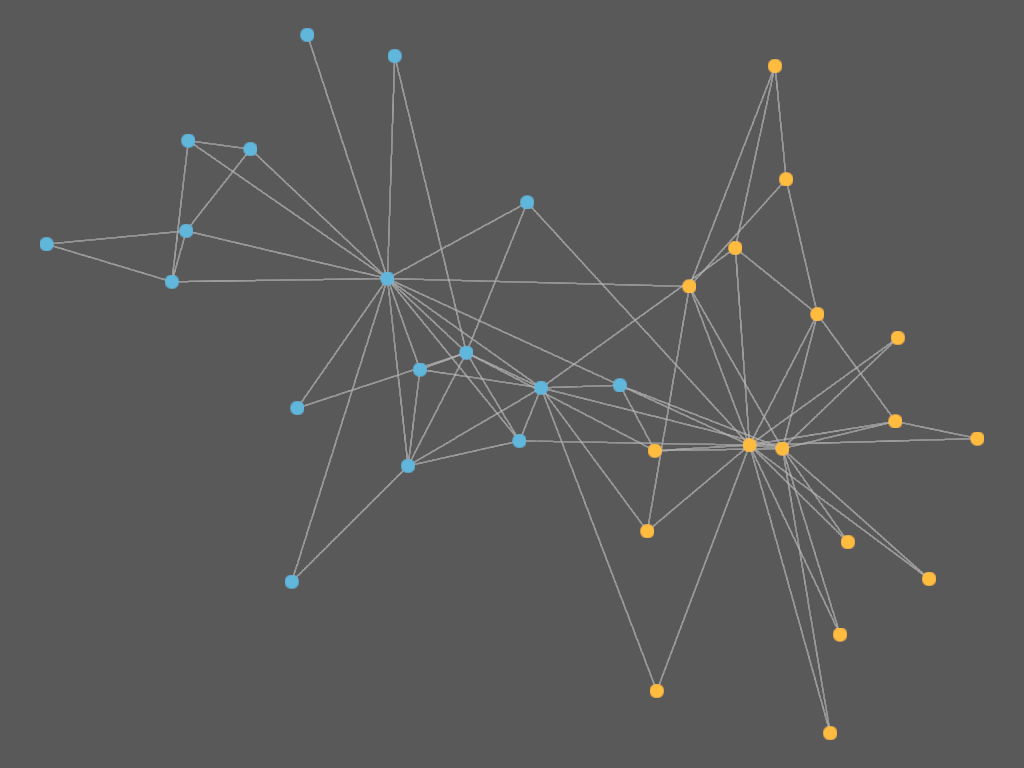

In [2]:
G = nx.karate_club_graph()
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

img = jv.graph(G, layout="spring", color_by="club",
               node_size=7.0, edge_size=1.0, edge_opacity=0.4,
               width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 2 — Barabási–Albert scale-free graph (500 nodes)

Nodes: 500, Edges: 1491
graph: 500 nodes, 1491 edges, 304,573 instances, render 79.6ms


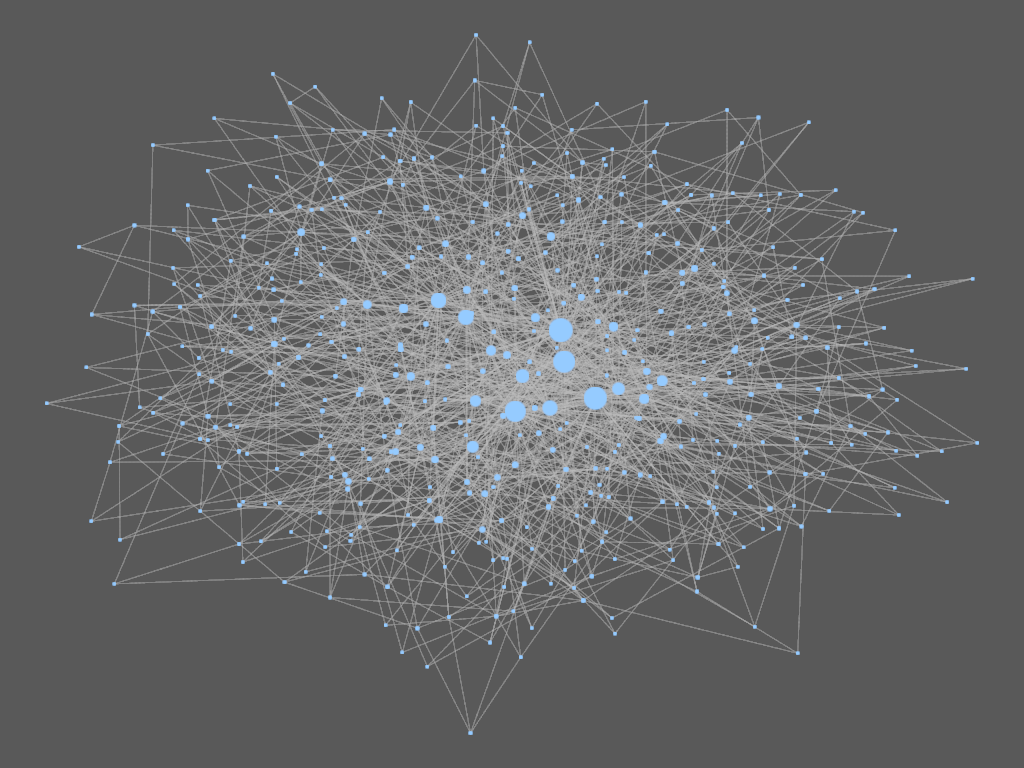

In [3]:
G_ba = nx.barabasi_albert_graph(500, 3, seed=42)
print(f"Nodes: {G_ba.number_of_nodes()}, Edges: {G_ba.number_of_edges()}")

# Size nodes by degree
nx.set_node_attributes(G_ba, dict(G_ba.degree()), "degree")

img = jv.graph(G_ba, layout="spring", size_by="degree",
               edge_size=0.8, edge_opacity=0.25,
               width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

## 3 — Different layout algorithms

layout=circular
graph: 30 nodes, 30 edges, 1,908 instances, render 3.2ms


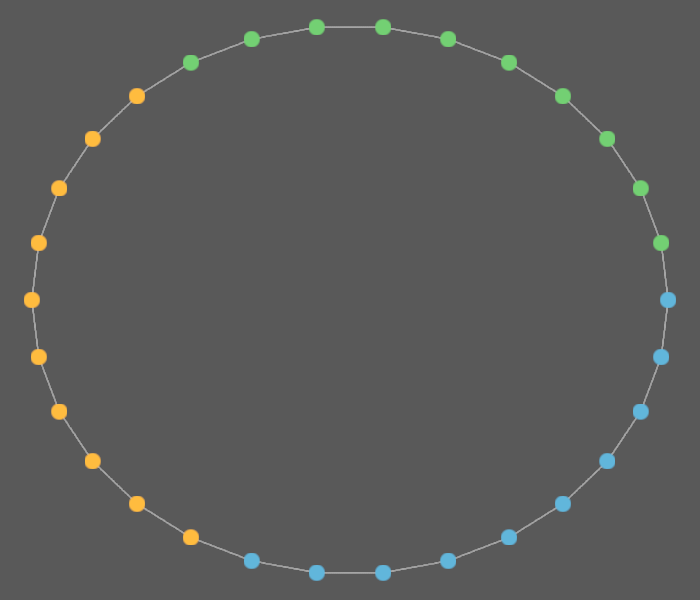

layout=spring
graph: 30 nodes, 30 edges, 2,094 instances, render 2.6ms


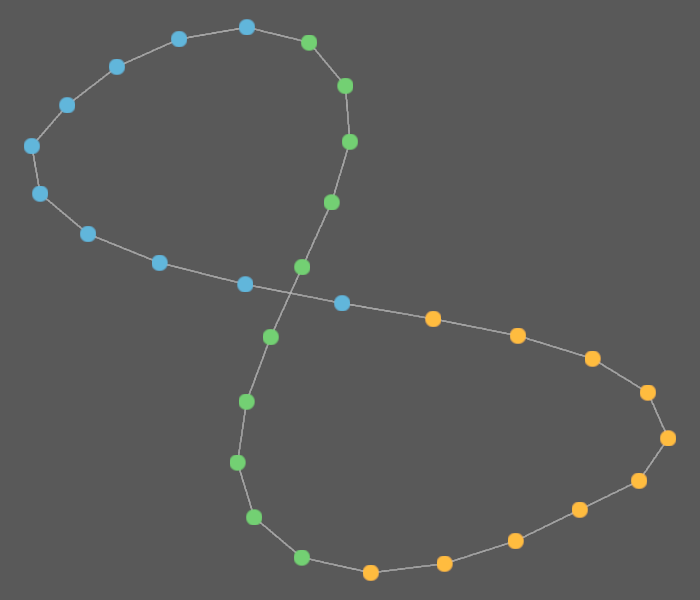

layout=spectral
graph: 30 nodes, 30 edges, 1,906 instances, render 2.6ms


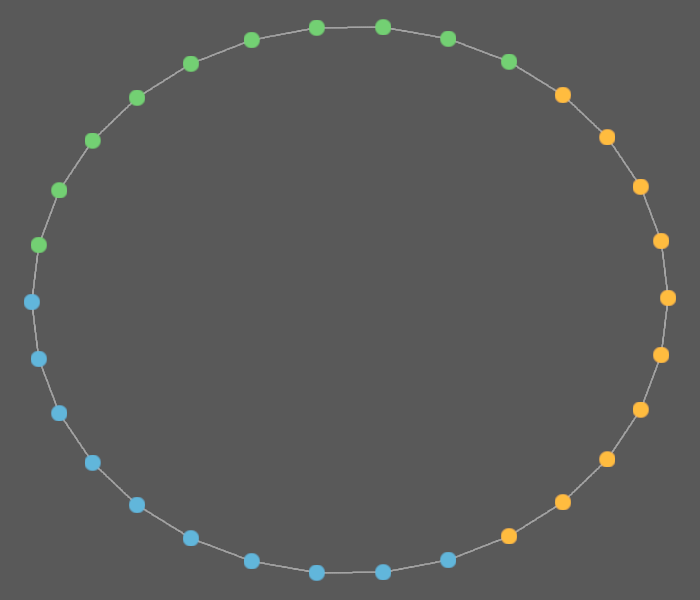

In [4]:
G_ring = nx.cycle_graph(30)
# Add a random attribute for coloring
rng = np.random.default_rng(0)
for n in G_ring.nodes():
    G_ring.nodes[n]["group"] = int(n // 10)

for layout in ["circular", "spring", "spectral"]:
    print(f"layout={layout}")
    img = jv.graph(G_ring, layout=layout, color_by="group",
                   node_size=8.0, edge_opacity=0.5, width=700, height=600)
    display(Image.fromarray(img, mode='RGBA'))

## 4 — Edge type layers (press 1/2/3 in interactive mode)

Edges with different `type` attributes are placed in separate layers so you can toggle them independently in the interactive window.

In [5]:
rng = np.random.default_rng(12)
G_multi = nx.MultiDiGraph()

# Add nodes
for i in range(20):
    G_multi.add_node(i, group=i % 4)

# Add edges of three types
edge_types = ["depends_on", "calls", "inherits"]
for _ in range(60):
    src = int(rng.integers(0, 20))
    dst = int(rng.integers(0, 20))
    if src != dst:
        etype = edge_types[int(rng.integers(0, 3))]
        G_multi.add_edge(src, dst, type=etype)

img = jv.graph(G_multi, layout="spring", color_by="group",
               edge_layers="type",
               node_size=7.0, edge_opacity=0.5, width=1024, height=768)
display(Image.fromarray(img, mode='RGBA'))

ValueError: not enough values to unpack (expected 3, got 2)

## 5 — Node + edge DataFrames

You can supply pre-computed (x, y) positions as a DataFrame.

graph: 30 nodes, 80 edges, 40,250 instances, render 13.7ms


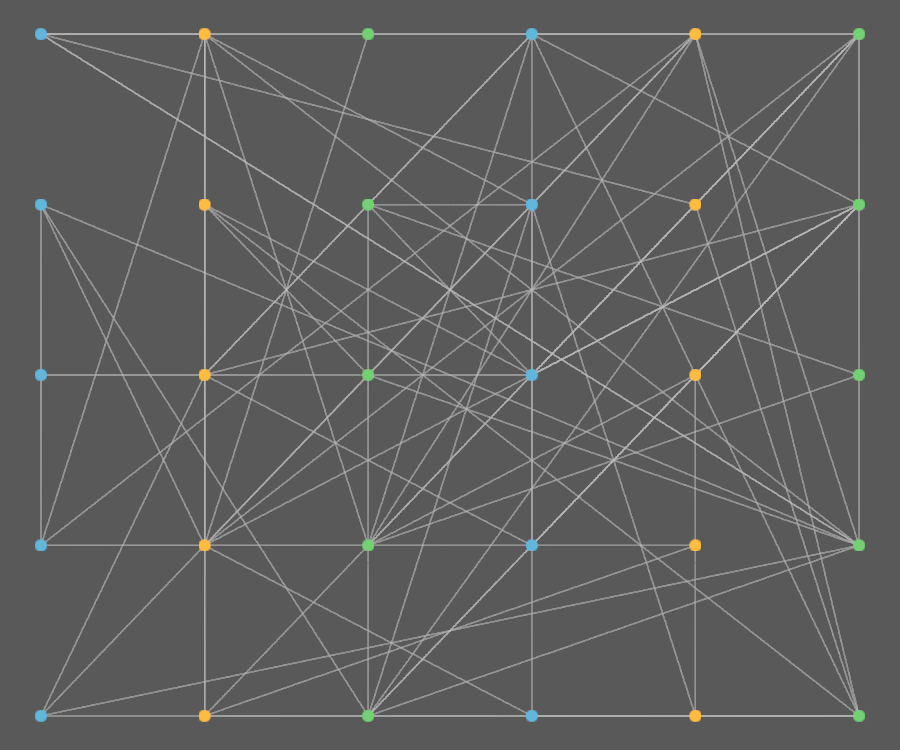

In [6]:
import pandas as pd

rng = np.random.default_rng(5)
n_nodes = 30
# Arrange nodes in a grid
gx, gy = np.meshgrid(np.linspace(0, 10, 6), np.linspace(0, 10, 5))
nodes_df = pd.DataFrame({
    "id":    np.arange(n_nodes),
    "x":     gx.ravel()[:n_nodes].astype(np.float32),
    "y":     gy.ravel()[:n_nodes].astype(np.float32),
    "group": (np.arange(n_nodes) % 3).astype(np.int32),
})

# Random edges
srcs = rng.integers(0, n_nodes, 80)
dsts = rng.integers(0, n_nodes, 80)
edges_df = pd.DataFrame({"source": srcs, "target": dsts})

img = jv.graph(nodes_df, edges_df=edges_df,
               x_col="x", y_col="y",
               source_col="source", target_col="target",
               color_by="group",
               node_size=6.0, edge_opacity=0.35, width=900, height=750)
display(Image.fromarray(img, mode='RGBA'))